# Erklärbare KI: Vorhersage des Beschäftigungswachstums 2024–2034 anhand von O*NET-Berufsmerkmalen

## Projektidee

Das Bureau of Labor Statistics (BLS) veröffentlicht Prognosen zur Beschäftigungsentwicklung
von Berufen in den USA für den Zeitraum 2024–2034. O*NET beschreibt dieselben Berufe anhand
detaillierter Merkmale wie benötigte Fähigkeiten, Wissen, Arbeitsaktivitäten, Arbeitskontext
und Arbeitsstile.

In diesem Projekt wird untersucht, ob und wie gut sich die von BLS prognostizierte
prozentuale Beschäftigungsänderung anhand dieser O*NET-Berufsmerkmale vorhersagen lässt.
Ein Random-Forest-Modell wird trainiert und anschließend mit **SHAP (SHapley Additive
exPlanations)** erklärt, um nachvollziehbar zu machen, welche Berufsmerkmale das Modell
für seine Vorhersage nutzt.

## Forschungsfrage

> Welche O*NET-Berufsmerkmale hängen am stärksten mit der vom BLS prognostizierten
> Beschäftigungswachstumsrate 2024–2034 zusammen, und wie lässt sich der Beitrag
> einzelner Merkmale zu einer konkreten Modellvorhersage mit SHAP erklären?

**Wichtiger Hinweis:** Es geht hier um statistische Zusammenhänge in historischen Daten,
nicht um eine gesicherte Zukunftsprognose (siehe Fazit am Ende des Notebooks).


## 1. Setup

Zuerst werden alle benötigten Bibliotheken importiert.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from functools import reduce
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import RidgeCV
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
DATASETS = "datasets"

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

/home/drmsalo/Projects/explainable_ai/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Daten laden und zusammenführen

### 2.1 O*NET-Dateien

Alle O*NET-Dateien liegen im *long format* vor: pro Beruf gibt es viele Zeilen
(eine pro Merkmal und Skala). Wir wandeln jede Datei in ein *wide format* um
(eine Zeile pro O*NET-SOC Code, eine Spalte pro Merkmal) und behalten dabei nur
die für uns relevante Skala:

| Datei | verwendete Scale ID | Bedeutung |
|---|---|---|
| Abilities | IM | Importance |
| Essential Skills | IM | Importance |
| Knowledge | IM | Importance |
| Work Activities | IM | Importance |
| Work Context | CX | numerische Rating-Skala (einzige numerische Skala der Datei) |
| Work Styles | WI | Work Styles Impact (einzige Zusatzskala neben dem Rank DR) |
| Job Zones | – | bereits im wide format, kein Pivot nötig (Spalte `Job Zone`) |

**Hinweis zur LV-Skala:** Abilities, Skills, Knowledge und Work Activities enthalten
zusätzlich eine *Level*-Skala (LV). Sie korreliert sehr stark mit der Importance-Skala
und bringt experimentell keinen Mehrwert für die Vorhersage – sie wird daher bewusst
nicht verwendet.

**Abweichung von der ursprünglichen Annahme:** "Essential Skills.xlsx" enthält hier nur die
10 sogenannten *Basic Skills* (z. B. Critical Thinking, Active Listening) – nicht die
vollständige O*NET-Skill-Taxonomie mit Cross-Functional Skills wie "Social Perceptiveness"
oder "Complex Problem Solving". Ebenso enthält "Work Styles.xlsx" eine etwas andere
Elementliste als die Standard-O*NET-Taxonomie (z. B. kein Element "Independence").
Da in Abschnitt 4 alle verfügbaren Merkmale verwendet werden, schränkt das nur die
Abdeckung der Taxonomie ein, nicht aber das Vorgehen.

In [2]:
def pivot_onet(filename, scale_id, prefix):
    df = pd.read_excel(f"{DATASETS}/{filename}")
    df = df[df["Scale ID"] == scale_id]
    wide = df.pivot_table(
        index="O*NET-SOC Code", columns="Element Name", values="Data Value", aggfunc="mean"
    )
    wide.columns = [f"{prefix}{c}" for c in wide.columns]
    return wide.reset_index()

onet_sources = [
    ("Abilities.xlsx", "IM", "ability_"),
    ("Essential Skills.xlsx", "IM", "skill_"),
    ("Knowledge.xlsx", "IM", "knowledge_"),
    ("Work Activities.xlsx", "IM", "activity_"),
    ("Work Context.xlsx", "CX", "context_"),
    ("Work Styles.xlsx", "WI", "style_"),
]

wide_frames = []
for filename, scale_id, prefix in onet_sources:
    wide = pivot_onet(filename, scale_id, prefix)
    print(f"{filename}: {wide.shape[0]} Berufe, {wide.shape[1] - 1} Merkmale (Prefix '{prefix}')")
    wide_frames.append(wide)

job_zones = pd.read_excel(f"{DATASETS}/Job Zones.xlsx")
job_zones = job_zones[["O*NET-SOC Code", "Job Zone"]].rename(columns={"Job Zone": "job_zone"})
print(f"Job Zones.xlsx: {job_zones.shape[0]} Berufe, 1 Merkmal (job_zone)")
wide_frames.append(job_zones)

Abilities.xlsx: 894 Berufe, 52 Merkmale (Prefix 'ability_')
Essential Skills.xlsx: 894 Berufe, 10 Merkmale (Prefix 'skill_')
Knowledge.xlsx: 894 Berufe, 33 Merkmale (Prefix 'knowledge_')
Work Activities.xlsx: 894 Berufe, 41 Merkmale (Prefix 'activity_')
Work Context.xlsx: 894 Berufe, 55 Merkmale (Prefix 'context_')
Work Styles.xlsx: 891 Berufe, 21 Merkmale (Prefix 'style_')
Job Zones.xlsx: 923 Berufe, 1 Merkmal (job_zone)


In [3]:
onet_merged = reduce(
    lambda left, right: pd.merge(left, right, on="O*NET-SOC Code", how="outer"),
    wide_frames,
)

occupation_data = pd.read_excel(f"{DATASETS}/Occupation Data.xlsx")
onet_merged = onet_merged.merge(
    occupation_data[["O*NET-SOC Code", "Title"]], on="O*NET-SOC Code", how="left"
)

print("Zusammengeführter O*NET-Datensatz:", onet_merged.shape)
onet_merged.head()

Zusammengeführter O*NET-Datensatz: (923, 215)


,O*NET-SOC Code,ability_Arm-Hand Steadiness,ability_Auditory Attention,ability_Category Flexibility,ability_Control Precision,ability_Deductive Reasoning,ability_Depth Perception,ability_Dynamic Flexibility,ability_Dynamic Strength,ability_Explosive Strength,ability_Extent Flexibility,ability_Far Vision,ability_Finger Dexterity,ability_Flexibility of Closure,ability_Fluency of Ideas,ability_Glare Sensitivity,ability_Gross Body Coordination,ability_Gross Body Equilibrium,ability_Hearing Sensitivity,ability_Inductive Reasoning,ability_Information Ordering,ability_Manual Dexterity,ability_Mathematical Reasoning,ability_Memorization,ability_Multilimb Coordination,...,context_Work With or Contribute to a Work Group or Team,context_Written Letters and Memos,style_Achievement Orientation,style_Adaptability,style_Attention to Detail,style_Cautiousness,style_Cooperation,style_Dependability,style_Empathy,style_Humility,style_Initiative,style_Innovation,style_Integrity,style_Intellectual Curiosity,style_Leadership Orientation,style_Optimism,style_Perseverance,style_Self-Confidence,style_Self-Control,style_Sincerity,style_Social Orientation,style_Stress Tolerance,style_Tolerance for Ambiguity,job_zone,Title
0,11-1011.00,1.38,2.12,3.50,1.75,4.12,1.75,1.0,1.25,1.00,1.00,3.00,1.50,3.25,3.88,1.25,1.0,1.00,2.12,4.00,4.00,1.00,3.25,2.88,1.75,...,4.36,4.14,2.91,2.69,1.44,1.03,1.53,2.93,1.07,-0.27,2.50,2.30,2.93,2.16,3.00,1.60,2.46,2.69,2.42,0.96,2.26,2.55,2.05,5,Chief Executives
1,11-1011.03,1.00,2.00,3.12,1.50,3.88,2.00,1.0,1.00,1.00,1.00,2.88,1.75,2.88,3.88,1.00,1.0,1.00,2.00,3.88,3.62,1.00,2.75,2.38,1.50,...,4.78,3.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,Chief Sustainability Officers
2,11-1021.00,1.62,2.12,3.38,1.12,3.88,1.88,1.0,1.12,1.38,1.25,2.62,1.50,2.62,3.25,1.00,1.5,1.38,1.75,3.50,3.50,1.50,2.88,2.25,1.50,...,4.62,4.01,2.38,2.05,1.74,1.32,1.84,2.65,1.22,0.12,2.22,1.60,2.51,1.44,2.93,1.39,2.19,2.28,2.14,0.94,1.97,1.99,1.64,4,General and Operations Managers
3,11-1031.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.28,2.38,1.47,1.00,2.18,2.65,1.77,-0.10,2.22,1.72,2.93,2.41,3.00,1.42,2.34,2.44,2.30,1.07,2.54,2.43,2.03,4,Legislators
4,11-2011.00,1.38,1.75,3.38,1.12,3.88,1.75,1.0,1.00,1.00,1.00,2.88,1.62,3.12,3.75,1.00,1.0,1.00,1.75,3.50,3.25,1.38,3.00,2.50,1.00,...,4.47,3.78,2.31,2.13,1.86,-0.44,1.84,2.22,0.95,-0.73,1.96,2.48,1.45,1.44,2.52,1.63,1.77,2.24,1.37,0.57,2.45,1.80,1.72,4,Advertising and Promotions Managers


### 2.2 O*NET-SOC Code auf 6-stellig kürzen und Unterberufe aggregieren

O*NET kennt teils mehrere Unterberufe pro BLS-Beruf (z. B. "11-1011.00" und "11-1011.03").
Damit ein Merge mit den BLS-Daten (6-stelliger SOC-Code) möglich ist, wird der Code
gekürzt. Das erzeugt Duplikate auf `soc_code`-Ebene, die wir durch Mittelwertbildung
der numerischen Merkmale je `soc_code` auflösen, **bevor** mit BLS gemergt wird.


In [4]:
onet_merged["soc_code"] = onet_merged["O*NET-SOC Code"].str.split(".").str[0]

n_unique_full = onet_merged["O*NET-SOC Code"].nunique()
n_unique_short = onet_merged["soc_code"].nunique()
print(f"Eindeutige O*NET-SOC Codes (8-stellig): {n_unique_full}")
print(f"Eindeutige soc_code (6-stellig):       {n_unique_short}")
print(f"Anzahl Zeilen, die durch Kürzung zu Duplikaten werden: "
      f"{len(onet_merged) - n_unique_short}")


Eindeutige O*NET-SOC Codes (8-stellig): 923
Eindeutige soc_code (6-stellig):       798
Anzahl Zeilen, die durch Kürzung zu Duplikaten werden: 125


In [5]:
feature_cols = [c for c in onet_merged.columns
                if c not in ("O*NET-SOC Code", "Title", "soc_code")]

onet_agg = onet_merged.sort_values("O*NET-SOC Code").groupby("soc_code", as_index=False)[feature_cols].mean()

titles = onet_merged.sort_values("O*NET-SOC Code").groupby("soc_code", as_index=False)["Title"].first()
onet_agg = onet_agg.merge(titles, on="soc_code", how="left")

print("Aggregierter O*NET-Datensatz (ein Beruf pro Zeile):", onet_agg.shape)
assert onet_agg["soc_code"].is_unique
onet_agg.head()

Aggregierter O*NET-Datensatz (ein Beruf pro Zeile): (798, 215)


,soc_code,ability_Arm-Hand Steadiness,ability_Auditory Attention,ability_Category Flexibility,ability_Control Precision,ability_Deductive Reasoning,ability_Depth Perception,ability_Dynamic Flexibility,ability_Dynamic Strength,ability_Explosive Strength,ability_Extent Flexibility,ability_Far Vision,ability_Finger Dexterity,ability_Flexibility of Closure,ability_Fluency of Ideas,ability_Glare Sensitivity,ability_Gross Body Coordination,ability_Gross Body Equilibrium,ability_Hearing Sensitivity,ability_Inductive Reasoning,ability_Information Ordering,ability_Manual Dexterity,ability_Mathematical Reasoning,ability_Memorization,ability_Multilimb Coordination,...,context_Work With or Contribute to a Work Group or Team,context_Written Letters and Memos,style_Achievement Orientation,style_Adaptability,style_Attention to Detail,style_Cautiousness,style_Cooperation,style_Dependability,style_Empathy,style_Humility,style_Initiative,style_Innovation,style_Integrity,style_Intellectual Curiosity,style_Leadership Orientation,style_Optimism,style_Perseverance,style_Self-Confidence,style_Self-Control,style_Sincerity,style_Social Orientation,style_Stress Tolerance,style_Tolerance for Ambiguity,job_zone,Title
0,11-1011,1.19,2.06,3.31,1.625,4.00,1.875,1.0,1.125,1.00,1.00,2.94,1.625,3.065,3.88,1.125,1.0,1.00,2.06,3.94,3.81,1.00,3.00,2.63,1.625,...,4.57,3.79,2.91,2.69,1.44,1.03,1.53,2.93,1.07,-0.27,2.50,2.30,2.93,2.16,3.00,1.60,2.46,2.69,2.42,0.96,2.26,2.55,2.05,5.0,Chief Executives
1,11-1021,1.62,2.12,3.38,1.120,3.88,1.880,1.0,1.120,1.38,1.25,2.62,1.500,2.620,3.25,1.000,1.5,1.38,1.75,3.50,3.50,1.50,2.88,2.25,1.500,...,4.62,4.01,2.38,2.05,1.74,1.32,1.84,2.65,1.22,0.12,2.22,1.60,2.51,1.44,2.93,1.39,2.19,2.28,2.14,0.94,1.97,1.99,1.64,4.0,General and Operations Managers
2,11-1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.28,2.38,1.47,1.00,2.18,2.65,1.77,-0.10,2.22,1.72,2.93,2.41,3.00,1.42,2.34,2.44,2.30,1.07,2.54,2.43,2.03,4.0,Legislators
3,11-2011,1.38,1.75,3.38,1.120,3.88,1.750,1.0,1.000,1.00,1.00,2.88,1.620,3.120,3.75,1.000,1.0,1.00,1.75,3.50,3.25,1.38,3.00,2.50,1.000,...,4.47,3.78,2.31,2.13,1.86,-0.44,1.84,2.22,0.95,-0.73,1.96,2.48,1.45,1.44,2.52,1.63,1.77,2.24,1.37,0.57,2.45,1.80,1.72,4.0,Advertising and Promotions Managers
4,11-2021,1.12,1.88,3.25,1.000,3.88,1.750,1.0,1.250,1.00,1.00,2.88,1.750,3.000,3.75,1.000,1.0,1.00,1.88,3.75,3.25,1.00,3.12,2.62,1.000,...,4.67,3.52,2.38,2.30,1.62,0.32,1.50,2.14,1.05,-0.50,2.03,2.48,1.73,1.97,2.40,1.46,1.87,2.20,1.43,0.62,2.20,1.80,1.72,4.0,Marketing Managers


### 2.3 BLS-Beschäftigungsdaten laden und bereinigen

Aus der BLS-Tabelle behalten wir nur Zeilen mit `Occupation type == "Line item"`
(Einzelberufe, keine Summenzeilen wie "Total, all occupations"). Die Zielspalte
`Employment change, percent, 2024–34` wird mit `pd.to_numeric(errors="coerce")`
bereinigt, da sie teils "—" statt einer Zahl enthalten kann.

Neben der Zielvariable behalten wir **Basisjahr-Kovariaten** (Stand 2024), die als
zusätzliche Merkmale dienen: Beschäftigung 2024, Medianlohn 2024, Anteil
Selbstständiger sowie die typische Ausbildung, Berufserfahrung und Einarbeitung.

**Vermeidung von Data Leakage:** Die Spalten `Employment, 2034`,
`Employment change, numeric, 2024–34` und `Occupational openings, 2024–34` werden
bewusst **nicht** übernommen – sie sind direkt aus der Zielvariable abgeleitet
(bzw. umgekehrt) und würden das Ergebnis künstlich aufblähen.

In [6]:
bls_raw = pd.read_excel(f"{DATASETS}/occupation.xlsx", sheet_name="Table 1.2", skiprows=1)
print("BLS Rohdaten:", bls_raw.shape)

bls = bls_raw[bls_raw["Occupation type"] == "Line item"].copy()

bls = bls.rename(columns={
    "2024 National Employment Matrix code": "soc_code",
    "2024 National Employment Matrix title": "occupation_title",
    "Employment change, percent, 2024–34": "employment_growth_pct",
    "Employment, 2024": "employment_2024",
    "Percent self employed, 2024": "pct_self_employed",
    "Median annual wage, dollars, 2024[1]": "median_wage_2024",
    "Typical education needed for entry": "education_entry",
    "Work experience in a related occupation": "work_experience",
    "Typical on-the-job training needed to attain competency in the occupation": "on_the_job_training",
})

bls = bls[[
    "soc_code", "occupation_title", "employment_growth_pct", "employment_2024",
    "pct_self_employed", "median_wage_2024", "education_entry",
    "work_experience", "on_the_job_training",
]]

for col in ["employment_growth_pct", "employment_2024", "pct_self_employed", "median_wage_2024"]:
    bls[col] = pd.to_numeric(bls[col], errors="coerce")

n_before = len(bls)
bls = bls.dropna(subset=["employment_growth_pct"])
print(f"Zeilen mit gültigem Zielwert: {len(bls)} von {n_before}")
bls.head()

BLS Rohdaten: (1117, 16)
Zeilen mit gültigem Zielwert: 832 von 832


,soc_code,occupation_title,employment_growth_pct,employment_2024,pct_self_employed,median_wage_2024,education_entry,work_experience,on_the_job_training
3,11-1011,Chief executives,4.3,309.4,25.9,206420.0,Bachelor's degree,5 years or more,NaN
4,11-1021,General and operations managers,4.4,3712.9,0.9,102950.0,Bachelor's degree,5 years or more,NaN
5,11-1031,Legislators,3.4,27.7,NaN,44810.0,Bachelor's degree,Less than 5 years,NaN
7,11-2011,Advertising and promotions managers,-2.2,27.0,20.7,126960.0,Bachelor's degree,Less than 5 years,NaN
9,11-2021,Marketing managers,6.6,407.0,3.6,161030.0,Bachelor's degree,5 years or more,NaN


### 2.4 Finaler Merge: O*NET-Merkmale + BLS-Zielvariable


In [7]:
df = onet_agg.merge(bls, on="soc_code", how="inner")
print("Finaler Datensatz:", df.shape)

assert len(df) == df["soc_code"].nunique(), "Duplikate im finalen Datensatz!"
print("OK: jede Zeile entspricht genau einem eindeutigen soc_code.")
df.head()

Finaler Datensatz: (773, 223)
OK: jede Zeile entspricht genau einem eindeutigen soc_code.


,soc_code,ability_Arm-Hand Steadiness,ability_Auditory Attention,ability_Category Flexibility,ability_Control Precision,ability_Deductive Reasoning,ability_Depth Perception,ability_Dynamic Flexibility,ability_Dynamic Strength,ability_Explosive Strength,ability_Extent Flexibility,ability_Far Vision,ability_Finger Dexterity,ability_Flexibility of Closure,ability_Fluency of Ideas,ability_Glare Sensitivity,ability_Gross Body Coordination,ability_Gross Body Equilibrium,ability_Hearing Sensitivity,ability_Inductive Reasoning,ability_Information Ordering,ability_Manual Dexterity,ability_Mathematical Reasoning,ability_Memorization,ability_Multilimb Coordination,...,style_Empathy,style_Humility,style_Initiative,style_Innovation,style_Integrity,style_Intellectual Curiosity,style_Leadership Orientation,style_Optimism,style_Perseverance,style_Self-Confidence,style_Self-Control,style_Sincerity,style_Social Orientation,style_Stress Tolerance,style_Tolerance for Ambiguity,job_zone,Title,occupation_title,employment_growth_pct,employment_2024,pct_self_employed,median_wage_2024,education_entry,work_experience,on_the_job_training
0,11-1011,1.19,2.06,3.31,1.625,4.00,1.875,1.0,1.125,1.00,1.00,2.94,1.625,3.065,3.88,1.125,1.0,1.00,2.06,3.94,3.81,1.00,3.00,2.63,1.625,...,1.07,-0.27,2.50,2.30,2.93,2.16,3.00,1.60,2.46,2.69,2.42,0.96,2.26,2.55,2.05,5.0,Chief Executives,Chief executives,4.3,309.4,25.9,206420.0,Bachelor's degree,5 years or more,NaN
1,11-1021,1.62,2.12,3.38,1.120,3.88,1.880,1.0,1.120,1.38,1.25,2.62,1.500,2.620,3.25,1.000,1.5,1.38,1.75,3.50,3.50,1.50,2.88,2.25,1.500,...,1.22,0.12,2.22,1.60,2.51,1.44,2.93,1.39,2.19,2.28,2.14,0.94,1.97,1.99,1.64,4.0,General and Operations Managers,General and operations managers,4.4,3712.9,0.9,102950.0,Bachelor's degree,5 years or more,NaN
2,11-1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.77,-0.10,2.22,1.72,2.93,2.41,3.00,1.42,2.34,2.44,2.30,1.07,2.54,2.43,2.03,4.0,Legislators,Legislators,3.4,27.7,NaN,44810.0,Bachelor's degree,Less than 5 years,NaN
3,11-2011,1.38,1.75,3.38,1.120,3.88,1.750,1.0,1.000,1.00,1.00,2.88,1.620,3.120,3.75,1.000,1.0,1.00,1.75,3.50,3.25,1.38,3.00,2.50,1.000,...,0.95,-0.73,1.96,2.48,1.45,1.44,2.52,1.63,1.77,2.24,1.37,0.57,2.45,1.80,1.72,4.0,Advertising and Promotions Managers,Advertising and promotions managers,-2.2,27.0,20.7,126960.0,Bachelor's degree,Less than 5 years,NaN
4,11-2021,1.12,1.88,3.25,1.000,3.88,1.750,1.0,1.250,1.00,1.00,2.88,1.750,3.000,3.75,1.000,1.0,1.00,1.88,3.75,3.25,1.00,3.12,2.62,1.000,...,1.05,-0.50,2.03,2.48,1.73,1.97,2.40,1.46,1.87,2.20,1.43,0.62,2.20,1.80,1.72,4.0,Marketing Managers,Marketing managers,6.6,407.0,3.6,161030.0,Bachelor's degree,5 years or more,NaN


### 2.5 Datenüberblick


In [8]:
print("Shape:", df.shape)
print()
print("Datentypen:\n", df.dtypes.value_counts())
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Spalten mit fehlenden Werten: {len(missing)} von {df.shape[1]}")
missing.head(15)


Shape: (773, 223)

Datentypen:
 float64    217
str          6
Name: count, dtype: int64

Spalten mit fehlenden Werten: 216 von 223


work_experience                   660
on_the_job_training               303
pct_self_employed                 190
ability_Arm-Hand Steadiness        22
ability_Deductive Reasoning        22
ability_Auditory Attention         22
ability_Category Flexibility       22
ability_Control Precision          22
ability_Explosive Strength         22
ability_Extent Flexibility         22
ability_Far Vision                 22
ability_Finger Dexterity           22
ability_Flexibility of Closure     22
ability_Fluency of Ideas           22
ability_Glare Sensitivity          22
dtype: int64

In [9]:
print("Anzahl vollständig doppelter Zeilen:", df.duplicated().sum())
print("Anzahl eindeutiger soc_code:", df['soc_code'].nunique(), "von", len(df), "Zeilen")


Anzahl vollständig doppelter Zeilen: 0
Anzahl eindeutiger soc_code: 773 von 773 Zeilen


## 3. Datenbereinigung

Die Zielvariable wurde bereits in Abschnitt 2.3 numerisch gemacht und ungültige Zeilen
wurden entfernt. Hier prüfen wir zusätzlich auf Duplikate **vor** einer eventuellen
Bereinigung, statt blind `drop_duplicates()` aufzurufen.


In [10]:
dup_titles = df[df.duplicated(subset=["occupation_title"], keep=False)]
print(f"Zeilen mit doppeltem occupation_title: {len(dup_titles)}")
dup_titles[["soc_code", "occupation_title", "employment_growth_pct"]].sort_values("occupation_title").head(10)

Zeilen mit doppeltem occupation_title: 0


,soc_code,occupation_title,employment_growth_pct


In [11]:
print("Fehlende Werte in der Zielvariable:", df['employment_growth_pct'].isna().sum())
print("Wertebereich der Zielvariable: "
      f"{df['employment_growth_pct'].min():.1f}% bis {df['employment_growth_pct'].max():.1f}%")

Fehlende Werte in der Zielvariable: 0
Wertebereich der Zielvariable: -36.1% bis 49.9%


## 4. Merkmalsdefinition und abgeleitete Merkmale

Es werden **alle verfügbaren O*NET-Merkmale** verwendet statt einer kleinen Handauswahl.
Eine Vorauswahl weniger Merkmale verwirft Information, die das Modell nutzen könnte –
für die Interpretierbarkeit ist sie nicht nötig, da SHAP die relevanten Merkmale im
trainierten Modell ohnehin identifiziert. Ein Random Forest ist zudem robust gegenüber
vielen, teils korrelierten Merkmalen.

Zusätzlich werden strukturelle Merkmale aus den BLS-Basisjahrdaten aufgenommen:

- `log_employment_2024`, `log_median_wage_2024` – logarithmiert, da Beschäftigung und
  Lohn stark rechtsschief verteilt sind,
- `pct_self_employed` – Anteil Selbstständiger 2024,
- `education_entry`, `work_experience`, `on_the_job_training` – typische
  Qualifikationsanforderungen (kategorial),
- `major_group` – die SOC-Berufshauptgruppe (erste zwei Stellen des SOC-Codes),
  da Wachstumsprognosen innerhalb einer Berufsgruppe ähnlich ausfallen.

Alle diese Merkmale beschreiben den Zustand im Basisjahr 2024 bzw. statische
Berufseigenschaften – sie enthalten keine Information über die Zielvariable
(siehe Leakage-Hinweis in Abschnitt 2.3).

In [12]:
onet_prefixes = ("ability_", "skill_", "knowledge_", "activity_", "context_", "style_")
onet_features = [c for c in df.columns if c.startswith(onet_prefixes)] + ["job_zone"]

df["major_group"] = df["soc_code"].str[:2]
df["log_employment_2024"] = np.log1p(df["employment_2024"])
df["log_median_wage_2024"] = np.log1p(df["median_wage_2024"])

numeric_features = onet_features + [
    "log_employment_2024", "log_median_wage_2024", "pct_self_employed",
]
categorical_features = [
    "education_entry", "work_experience", "on_the_job_training", "major_group",
]
feature_columns = numeric_features + categorical_features

print(f"O*NET-Merkmale:        {len(onet_features)}")
print(f"Numerische Merkmale:   {len(numeric_features)}")
print(f"Kategoriale Merkmale:  {len(categorical_features)}")
print(f"Merkmale gesamt:       {len(feature_columns)}")

O*NET-Merkmale:        213
Numerische Merkmale:   216
Kategoriale Merkmale:  4
Merkmale gesamt:       220


In [13]:
def feature_group(col):
    for prefix in onet_prefixes:
        if col.startswith(prefix):
            return prefix.rstrip("_")
    return "struktur (BLS/SOC)"

feature_overview = pd.DataFrame({
    "group": [feature_group(c) for c in feature_columns],
    "missing": df[feature_columns].isna().sum().values,
})
feature_overview.groupby("group").agg(
    n_features=("group", "size"), missing_values=("missing", "sum")
)

,n_features,missing_values
group,,
ability,52,1144
activity,41,902
context,55,1210
knowledge,33,726
skill,10,220
struktur (BLS/SOC),8,1174
style,21,42


## 5. Train-Test-Split

Der Split erfolgt direkt nach der Feature-Auswahl, **bevor** Imputer/Scaler gefittet
werden – so fließen keine Informationen aus dem Testset in die Vorverarbeitung ein
(kein Data Leakage).


In [14]:
X = df[feature_columns]
y = df["employment_growth_pct"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training:", X_train.shape, " Test:", X_test.shape)

Training: (618, 220)  Test: (155, 220)


## 6. Baseline und Ridge Regression

Als Baseline dient ein `DummyRegressor` (sagt immer den Mittelwert vorher). Die
Ridge Regression läuft in einer Pipeline mit Median-Imputation und Standardisierung
für numerische sowie One-Hot-Encoding für kategoriale Merkmale, damit die gesamte
Vorverarbeitung ausschließlich auf den Trainingsdaten gefittet wird. Die
Regularisierungsstärke `alpha` wird mit `RidgeCV` per Kreuzvalidierung auf den
Trainingsdaten bestimmt – bei über 200 teils stark korrelierten Merkmalen ist
eine passend gewählte Regularisierung entscheidend.

In [15]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

ridge_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 4, 30))),
])
ridge_pipeline.fit(X_train, y_train)
print(f"Gewähltes alpha: {ridge_pipeline.named_steps['ridge'].alpha_:.1f}")

Gewähltes alpha: 221.2


## 7. Random Forest mit Hyperparameter-Suche

Als Hauptmodell dient ein `RandomForestRegressor`. Numerische Merkmale werden
median-imputiert, kategoriale ordinal kodiert (für Baummodelle ausreichend und
sparsamer als One-Hot). Die Hyperparameter werden mit `RandomizedSearchCV`
(5-fach Kreuzvalidierung, nur auf den Trainingsdaten) optimiert. Als
Suchkriterium dient `scoring="r2"`, also direkt die Metrik, an der das Modell
gemessen wird. Der Suchraum erlaubt tiefe Bäume mit kleinen Blättern – bei
vielen schwach informativen Merkmalen braucht der Wald genug Tiefe, um Struktur
zu erfassen; die Mittelung über viele Bäume verhindert Überanpassung.

In [16]:
tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
], verbose_feature_names_out=False)

rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("rf", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_distributions = {
    "rf__n_estimators": [400, 600, 800],
    "rf__max_depth": [None, 15, 25],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": [0.2, 0.33, 0.5, "sqrt"],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_search.fit(X_train, y_train)

print("Beste Parameter:", rf_search.best_params_)
print(f"Bestes CV-R²: {rf_search.best_score_:.3f}")
best_rf = rf_search.best_estimator_

Beste Parameter: {'rf__n_estimators': 400, 'rf__min_samples_leaf': 4, 'rf__max_features': 0.2, 'rf__max_depth': 15}
Bestes CV-R²: 0.352


## 8. Modellbewertung

MAE, RMSE und R² auf den Testdaten sowie das Kreuzvalidierungs-R² auf den
Trainingsdaten werden für alle drei Modelle verglichen.

In [17]:
def evaluate(model, X_tr, y_tr, X_te, y_te, cv):
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    r2 = r2_score(y_te, pred)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="r2").mean()
    return mae, rmse, r2, cv_r2

results = {}
for name, model in [("Baseline (Mittelwert)", baseline),
                    ("Ridge Regression", ridge_pipeline),
                    ("Random Forest", best_rf)]:
    mae, rmse, r2, cv_r2 = evaluate(model, X_train, y_train, X_test, y_test, cv)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "CV-R2 (Train)": cv_r2}

results_df = pd.DataFrame(results).T.round(3)
results_df

,MAE,RMSE,R2,CV-R2 (Train)
Baseline (Mittelwert),5.118,7.135,-0.009,-0.001
Ridge Regression,4.353,5.928,0.303,0.349
Random Forest,4.149,5.834,0.325,0.352


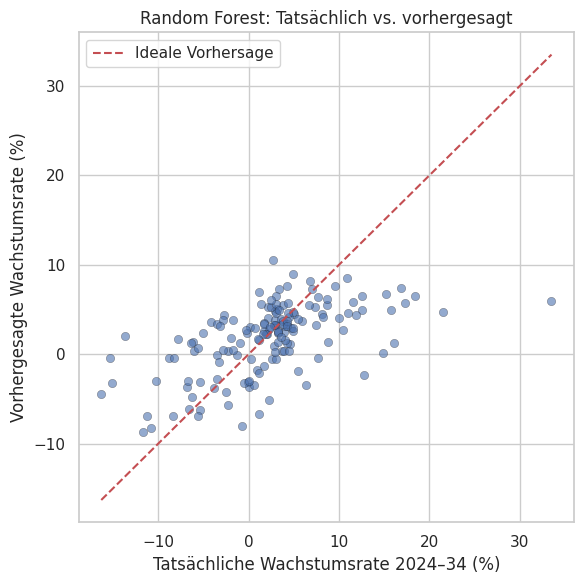

In [18]:
rf_pred = best_rf.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, rf_pred, alpha=0.6, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), rf_pred.min()), max(y_test.max(), rf_pred.max())]
ax.plot(lims, lims, "r--", label="Ideale Vorhersage")
ax.set_xlabel("Tatsächliche Wachstumsrate 2024–34 (%)")
ax.set_ylabel("Vorhergesagte Wachstumsrate (%)")
ax.set_title("Random Forest: Tatsächlich vs. vorhergesagt")
ax.legend()
plt.tight_layout()
plt.show()


In [19]:
error_table = X_test.copy()
error_table["occupation_title"] = df.loc[X_test.index, "occupation_title"]
error_table["actual"] = y_test
error_table["predicted"] = rf_pred
error_table["abs_error"] = (error_table["actual"] - error_table["predicted"]).abs()

top_errors = error_table.sort_values("abs_error", ascending=False).head(5)
top_errors[["occupation_title", "actual", "predicted", "abs_error"]].round(2)


,occupation_title,actual,predicted,abs_error
86,Data scientists,33.5,5.98,27.52
84,Operations research analysts,21.5,4.75,16.75
235,"Adult basic education, adult secondary e...",-13.7,2.07,15.77
719,Computer numerically controlled tool p...,12.8,-2.29,15.09
690,Nuclear power reactor operators,-15.3,-0.42,14.88


## 9. Erklärbarkeit mit SHAP

Mit `TreeExplainer` berechnen wir SHAP-Werte für das beste Random-Forest-Modell.
Diese zeigen, wie stark und in welche Richtung jedes Merkmal die Vorhersage für
einen bestimmten Beruf im Vergleich zum Durchschnitt verschiebt.


In [20]:
rf_model = best_rf.named_steps["rf"]
preprocessor = best_rf.named_steps["preprocessor"]

feature_names = list(preprocessor.get_feature_names_out())
X_test_prepared = pd.DataFrame(
    preprocessor.transform(X_test), columns=feature_names, index=X_test.index
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_prepared)

### Globale Merkmalswichtigkeit (Bar-Plot)

Der Bar-Plot zeigt, welche Merkmale im Durchschnitt über alle Testberufe den größten
Einfluss auf die Vorhersage haben (unabhängig von der Richtung des Effekts).


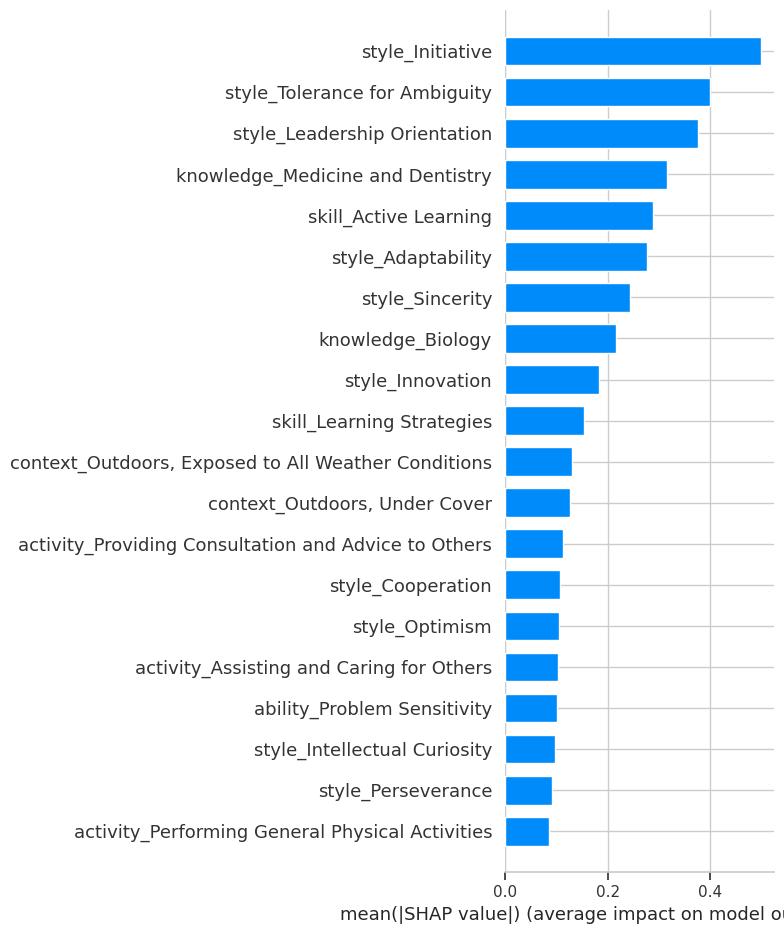

In [21]:
shap.summary_plot(shap_values, X_test_prepared, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### Beeswarm-Plot

Der Beeswarm-Plot zeigt zusätzlich, ob hohe (rot) oder niedrige (blau) Merkmalswerte
die Vorhersage erhöhen oder senken.


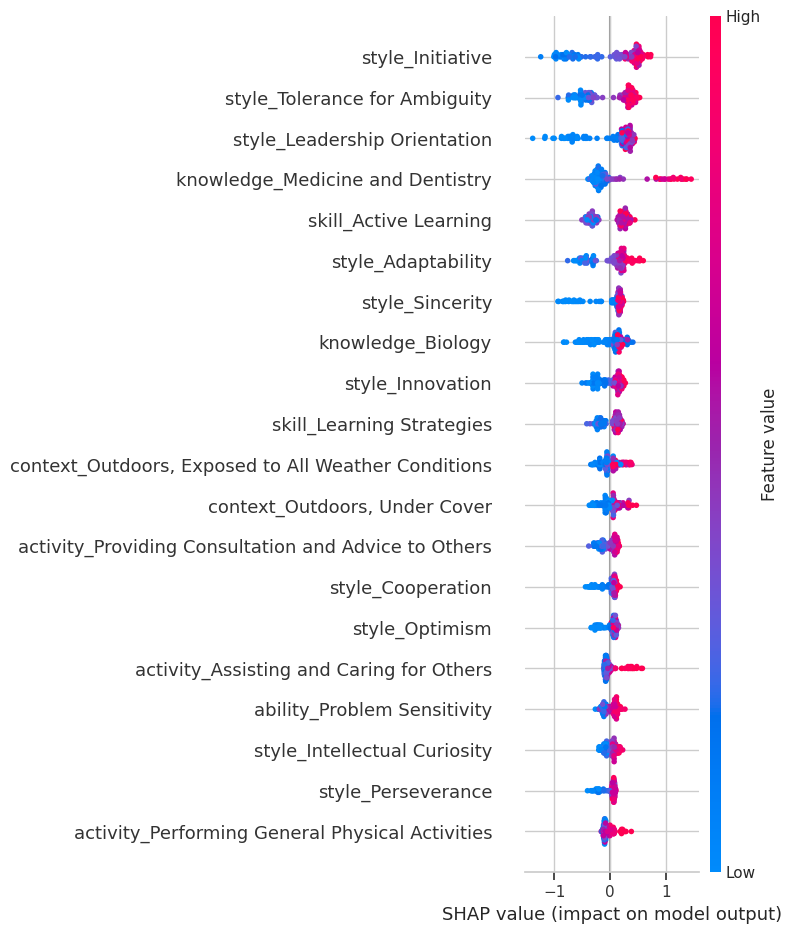

In [22]:
shap.summary_plot(shap_values, X_test_prepared, show=False)
plt.tight_layout()
plt.show()

### Einzelfall-Erklärungen (Waterfall-Plots)

Wir betrachten je einen Beruf mit hoher und einen mit niedriger vorhergesagter
Wachstumsrate. Falls "Data Scientists" bzw. "Cashiers" im Testset vorhanden sind,
werden diese verwendet – sonst werden automatisch der Beruf mit der höchsten bzw.
niedrigsten Vorhersage im Testset gewählt.


In [23]:
titles_test = df.loc[X_test.index, "occupation_title"]

def find_case(name_substring):
    matches = titles_test[titles_test.str.contains(name_substring, case=False, na=False)]
    return matches.index[0] if len(matches) else None

high_idx = find_case("Data Scientist")
low_idx = find_case("Cashier")

pred_series = pd.Series(rf_pred, index=X_test.index)
if high_idx is None:
    high_idx = pred_series.idxmax()
if low_idx is None:
    low_idx = pred_series.idxmin()

print("Hohe Wachstumsrate:", titles_test.loc[high_idx], f"({pred_series.loc[high_idx]:.1f}%)")
print("Niedrige Wachstumsrate:", titles_test.loc[low_idx], f"({pred_series.loc[low_idx]:.1f}%)")


Hohe Wachstumsrate:       Data scientists (6.0%)
Niedrige Wachstumsrate:         Textile cutting machine setters, operators, and tenders (-8.7%)


In [ ]:
expected_value = np.asarray(explainer.expected_value).reshape(-1)[0]

def plot_waterfall(idx, title):
    pos = X_test.index.get_loc(idx)
    explanation = shap.Explanation(
        values=shap_values[pos],
        base_values=expected_value,
        data=X_test_prepared.loc[idx].values,
        feature_names=feature_names,
    )
    shap.plots.waterfall(explanation, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_waterfall(high_idx, f"Waterfall: {titles_test.loc[high_idx]} (hohe Vorhersage)")

In [ ]:
plot_waterfall(low_idx, f"Waterfall: {titles_test.loc[low_idx]} (niedrige Vorhersage)")


### Einordnung der SHAP-Ergebnisse (einfach erklärt)

Jeder Balken im Waterfall-Plot zeigt, wie stark ein einzelnes Berufsmerkmal die
Vorhersage für diesen Beruf im Vergleich zum durchschnittlichen Modellwert (Basiswert)
nach oben (rot) oder unten (blau) verschiebt. Merkmale, die im Bar- und Beeswarm-Plot
weit oben stehen, sind über viele Berufe hinweg besonders einflussreich – das Modell
"achtet" bei seiner Vorhersage am stärksten auf sie. Das bedeutet nicht automatisch,
dass diese Merkmale den Beruf ursächlich wachsen oder schrumpfen lassen – es zeigt nur,
dass Berufe mit ähnlichen Merkmalsausprägungen in den historischen Daten oft ähnliche
BLS-Wachstumsprognosen hatten.


## 10. Fazit

Das Modell kann einen Teil der Unterschiede zwischen den BLS-Wachstumsprognosen
anhand von O*NET-Berufsmerkmalen erklären. Die SHAP-Analyse macht sichtbar, welche
Merkmale dabei für das Modell besonders relevant sind, und macht einzelne
Vorhersagen nachvollziehbar.

Die Ergebnisse zeigen jedoch **Zusammenhänge in den Daten, aber keine sicheren
Ursachen und keine Garantie für die tatsächliche Entwicklung der Berufe bis 2034**.
Die BLS-Prognosen selbst basieren auf Annahmen über wirtschaftliche, technologische
und demografische Entwicklungen, die sich ändern können. Das Modell in diesem
Notebook lernt lediglich Muster aus diesen bestehenden Prognosen und den
Berufsmerkmalen – es trifft keine eigenständige, unabhängige Vorhersage über die
Zukunft.
